<a href="https://colab.research.google.com/github/babi00/ai4biological-pattern/blob/guido-clean/invasive_plants_analysis/image_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Classificatore specie:
- input: immagine
- output label: nativa/non nativa e non invasiva/non nativa e invasiva
La struttura del modello utilizzato è simile a quella precedentemente implementata:
le immagini passano attraverso un modello preallenato (BioCLIP o ResNet) da cui vengono estratti gli embedding
gli embedding allenano un semplice classificatore.

La loss function è stata modificata: ogni classe ha il suo peso (dipendente dalla frequenza della classe).

Durante il training le fasi di estrazione degli embedding e predizione del label sono separate (così che il training sia molto più veloce e leggero). Una volta finito il training viene ricostruito il modello intero, così che il classificatore prenda come input l'immagine (non l'embedding) e restituisca il label (in modo che si possa effettuare successivamente explainability sulle immagini e non solo sugli embedding).

Rispetto al modello di Barbara, estraggo gli embeddings tutti insieme (e non separati per training set e validation set), così da poter effettuare cross validation senza dover ogni volta estrarre gli embeddings.

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
# from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, multilabel_confusion_matrix, confusion_matrix, ConfusionMatrixDisplay, f1_score
# import seaborn as sns
# import requests
# from io import BytesIO
from google.colab import drive
import time
from tqdm import tqdm
!pip install open_clip_torch
import open_clip
# import random
import math
from collections import Counter
from torch.utils.data import Subset

torch.manual_seed(42)
np.random.seed(42)

drive.mount('/content/drive')

# Clone the repository and checkout the 'clean-barbara' branch
!git clone --branch clean-barbara https://github.com/babi00/ai4biological-pattern.git
%cd ai4biological-pattern

# Enable sparse checkout
!git sparse-checkout init --cone

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cloning into 'ai4biological-pattern'...
remote: Enumerating objects: 734656, done.
remote: Counting objects: 100% (192/192), done.
remote: Compressing objects: 100% (138/138), done.
remote: Total 734656 (delta 116), reused 117 (delta 53), pack-reused 734464 (from 3)
Receiving objects: 100% (734656/734656), 8.35 GiB | 35.95 MiB/s, done.
Resolving deltas: 100% (2037/2037), done.
Updating files: 100% (214630/214630), done.
/content/ai4biological-pattern/ai4biological-pattern
Updating files: 100% (214628/214628), done.


In [4]:
#new version: trying to save memory..
class InvasiveSpeciesDataset(Dataset):
    def __init__(self, root_dir, transform=None, get_label_fn=None):
        self.root_dir = root_dir
        self.transform = transform
        self.entries = []
        self.label_map = {
            "native": 0,
            "introduced non-invasive": 1,
            "invasive": 2
        }

        taxa_folders = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d)) and d not in ["metadata", "filtered_metadata"]]

        print(f"🔎 Dataset root directory: {root_dir}")
        print(f"📁 Taxa folders found: {taxa_folders}")
        for taxon in taxa_folders:
            meta_path = os.path.join(root_dir, "filtered_metadata", f"{taxon}_metadata.csv")
            if not os.path.exists(meta_path):
                print(f"🚫 Metadata file not found for taxon: {taxon} at {meta_path}")
                continue
            metadata_df = pd.read_csv(meta_path)
            for idx, row in metadata_df.iterrows():
                self.entries.append((taxon, row))  # Just index, don’t open anything

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        taxon, row = self.entries[idx]
        filename = str(row["filename"])
        image_path = os.path.join(self.root_dir, taxon, filename)
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = self.label_map.get(row["label"])
        return image, label, idx

In [5]:
#Return the dataloader of all images and not already separated (also class weights are not present)
def get_data_loader(root_dir, batch_size=32, use_bioclip=True, preprocess=None):
    if use_bioclip and preprocess:
        transform = preprocess
    else:
        transform = transforms.Compose([
          transforms.Resize((224, 224)),
          transforms.ToTensor()
        ])

    dataset = InvasiveSpeciesDataset(
        root_dir=root_dir,
        transform=transform,
    )

    # train_size = int(0.8 * len(dataset))
    # val_size = len(dataset) - train_size
    # train_data, val_data = random_split(dataset, [train_size, val_size])

    # label_counts = Counter()
    # for _, label, _ in train_data:
    #     label_counts[label] += 1

    # print("🔢 Class distribution in train set:", label_counts)

    # total = sum(label_counts.values())
    # class_weights = torch.tensor([
    #     1.0 / math.log(1.02 + label_counts[0]),
    #     1.0 / math.log(1.02 + label_counts[1]),
    #     1.0 / math.log(1.02 + label_counts[2]),
    # ], dtype=torch.float)

    # print("⚖️ Class weights:", class_weights)

    # train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
    # val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

    loader = DataLoader(dataset, batch_size=32, shuffle=False)

    return loader

In [6]:
#2.Define the embedding extractor:
#ResNet without the last FC layer
def get_resnet_embeddings_extractor_model():
    #Use a pre-trained ResNet18 model
    model = models.resnet18(weights='IMAGENET1K_V1')

    #Freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    embeddings_extractor= nn.Sequential(*list(model.children())[:-1]) #removes the last FC layer
    print("Model obtained...")

    return embeddings_extractor

#BioCLIP model
def get_bioclip_embeddings_extractor_model(device, bioclip_version=2):
    if bioclip_version==2:
        print("BioCLIP 2!")
        model, _, preprocess = open_clip.create_model_and_transforms('hf-hub:imageomics/bioclip-2')
    else:
        model, _, preprocess = open_clip.create_model_and_transforms('hf-hub:imageomics/bioclip')
    print("Model obtained...")
    model.to(device)
    model.eval()
    return model, preprocess

In [20]:
#3.Extract embeddings using the embeddings_extractor and return the embeddings tensors
def extract_embeddings(dataloader, embeddings_extractor, device, embeddings_save_path, use_bioclip=True):
    print("Entered EXTRACT_EMBEDDINGS")
    embeddings_extractor.eval()
    all_embeddings = []
    all_labels = []
    all_ids = []

    if use_bioclip:
      with torch.no_grad():
        for images, labels, obs_id in tqdm(dataloader, desc='Extracting embeddings'):
            images = images.to(device)
            embeddings = embeddings_extractor.encode_image(images)
            embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)  # Optional: normalize
            all_embeddings.append(embeddings.cpu())
            all_labels.append(labels)
            all_ids.extend(obs_id)

    else:
      with torch.no_grad():
        for images, labels, obs_id in tqdm(dataloader, desc='Extracting embeddings'):
            images = images.to(device)
            embeddings = embeddings_extractor(images).view(images.size(0), -1)
            all_embeddings.append(embeddings.cpu())
            all_labels.append(labels)
            all_ids.extend(obs_id)

    embeddings_tensors = torch.cat(all_embeddings, dim=0).to(device)
    labels_tensors = torch.cat(all_labels, dim=0).to(device)
    obs_id_tensor = torch.tensor(all_ids).to(device)

    all_embeddings = {
       'embeddings' : embeddings_tensors,
       'labels' : labels_tensors,
       'ids' : obs_id_tensor
    }

    torch.save(all_embeddings, embeddings_save_path)

    # dataset = torch.utils.data.TensorDataset(embeddings_tensors, labels_tensors, obs_id_tensor)
    # loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

    # embedding_size = embeddings_tensors.shape[1] #useful for classifier

    return all_embeddings

In [19]:
def split_embeddings(embeddings_dict, val_percentage=0.2):

    """Split the embeddings and not the images into training set and validation set"""

    print("SPLITTING EMBEDDINGS")
    embeddings_tensors = embeddings_dict["embeddings"]
    labels_tensors = embeddings_dict["labels"]
    obs_id_tensor = embeddings_dict["ids"]

    embedding_size = embeddings_tensors.shape[1] #useful for classifier

    dataset = torch.utils.data.TensorDataset(embeddings_tensors, labels_tensors, obs_id_tensor)

    train_size = int((1-val_percentage) * len(dataset))
    val_size = len(dataset) - train_size

    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    label_counts = Counter()
    for _, label, _ in train_dataset:
        label_counts[label] += 1


    # total = sum(label_counts.values())
    class_weights = torch.tensor([
        1.0 / math.log(1.02 + label_counts[0]),
        1.0 / math.log(1.02 + label_counts[1]),
        1.0 / math.log(1.02 + label_counts[2]),
    ], dtype=torch.float)

    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=True)

    return train_loader, val_loader, class_weights, embedding_size

In [9]:
#Classifier
class InvasiveSpeciesClassifier(nn.Module):
    def __init__(self, embedding_dim, hidden_dim=256, num_classes=3):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(), #consider adding a Dropout layer
            # nn.Dropout(0.3), #We remove the dropout layer
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.classifier(x)

In [10]:
#4. Training function
def train_classifier(train_loader, val_loader, feature_extractor, classifier, optimizer, criterion, device, output_dir, model_name, num_epoch=3):

    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    for epoch in range(num_epoch):
        print(f"\n🔁 Epoch {epoch + 1}/{num_epoch}")
        classifier.train()
        running_loss, correct, total = 0, 0, 0

        for embeddings, labels, _ in tqdm(train_loader, desc="Training"): # Unpack all three values
            outputs = classifier(embeddings)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * embeddings.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        val_loss, val_acc, y_true, y_pred = evaluate_classifier(
            val_loader, feature_extractor, classifier, criterion, device
        )

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"📉 Train Loss: {train_loss:.4f} | Accuracy: {train_acc:.4f}")
        print(f"📈 Val Loss:   {val_loss:.4f} | Accuracy: {val_acc:.4f}")

        print("\n📋 Classification Report:")
        print(classification_report(y_true, y_pred, labels=[0, 1, 2], target_names=["Native", "NN Non-Invasive", "NN Invasive"], zero_division=0))

        #plot confuzion matrix
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
        fig, ax = plt.subplots(figsize=(6, 6))
        im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        ax.figure.colorbar(im, ax=ax)
        classes = ["Native", "NN-NI", "NN-I"]

        # Show all ticks and label them
        ax.set(xticks=np.arange(len(classes)),
              yticks=np.arange(len(classes)),
              xticklabels=classes,
              yticklabels=classes,
              ylabel='True label',
              xlabel='Predicted label',
              title='Validation Confusion Matrix')

        # Rotate the tick labels and set alignment.
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

        # Loop over data dimensions and create text annotations.
        fmt = 'd'
        thresh = cm.max() / 2. if cm.max() > 0 else 1
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, format(cm[i, j], fmt),
                        ha="center", va="center",
                        color="white" if cm[i, j] > thresh else "black")

        fig.tight_layout()
        plt.grid(False)
        plt.show()


    torch.save(classifier.state_dict(), f'classifier_head_{model_name}.pth')
    google_drive_path = f'/content/drive/MyDrive/Thesis/{output_dir}/classifier_head_{model_name}.pth'
    torch.save(classifier.state_dict(), google_drive_path)

    return train_losses, train_accuracies, val_losses, val_accuracies

In [11]:
#5. Evaluation function
def evaluate_classifier(loader, feature_extractor, classifier, criterion, device):
    classifier.eval()
    total_loss, correct, total = 0, 0, 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for embeddings, labels, obs_ids in tqdm(loader, desc="Evaluating"): # Unpack all three values
            embeddings, labels = embeddings.to(device), labels.to(device)
            outputs = classifier(embeddings)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * embeddings.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total
    avg_acc = correct / total

    return avg_loss, avg_acc, all_labels, all_preds

In [12]:
class FullModel(nn.Module):
    def __init__(self, embedding_model, classifier_head):
        super().__init__()
        self.embedding_model = embedding_model
        self.classifier_head = classifier_head

    def forward(self, x):
        with torch.no_grad():
            if hasattr(self.encoder, 'encode_image'):
                features = self.encoder.encode_image(x)
            else:
                features = self.encoder(x)

        if features.ndim == 4:
            features = features.view(features.size(0), -1)

        return self.classifier_head(features)

In [23]:
def create_model_and_predict(folder_name="taxas", use_bioclip=True, bioclip_version=None, output_dir="invasive_species", model_name="prova", embeddings_save_path=None, debug_subset_size=None):
    start_time = time.time()

    model_name = f'bioclip_2_{model_name}' if use_bioclip and bioclip_version==2 else f'bioclip_1_{model_name}' if use_bioclip else f'resnet_{model_name}'

    github = '/content/ai4biological-pattern/barbara_new'
    github_repository = f'{github}/{folder_name}'

    if not os.path.isdir(github_repository): #check if data has already been downloaded
        !git sparse-checkout set barbara_new/{folder_name}
        !git checkout clean-barbara

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    if use_bioclip:
        feature_extractor, preprocess = get_bioclip_embeddings_extractor_model(device, bioclip_version)
        feature_extractor = feature_extractor.to(device)
    else:
        feature_extractor = get_resnet_embeddings_extractor_model()
        feature_extractor = feature_extractor.to(device)
        preprocess = None
    print("Feature extractor obtained..")


    if os.path.exists(embeddings_save_path):
        print("✅ Embeddings already exist, loading from file...")
        embeddings_dict = torch.load(embeddings_save_path)
    else:
        img_loader = get_data_loader(root_dir=github_repository)

        print("Dataloader obtained..")

        #this function also saves embeddings in the desired path
        #input size is the same for training and validation, is is the size (number of features) of the single embedding.
        embeddings_dict = extract_embeddings(img_loader, feature_extractor, device, embeddings_save_path, use_bioclip)



    if debug_subset_size is not None:
      print(f"⚠ Debug mode: using only the first {debug_subset_size} embeddings.")
      embeddings_dict['embeddings'] = embeddings_dict['embeddings'][:debug_subset_size]
      embeddings_dict['labels'] = embeddings_dict['labels'][:debug_subset_size]
      embeddings_dict['ids'] = embeddings_dict['ids'][:debug_subset_size]

    embeddings_train_loader, embeddings_val_loader, class_weights, input_size = split_embeddings(embeddings_dict, val_percentage=0.2)

    classifier = InvasiveSpeciesClassifier(embedding_dim=input_size).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = optim.Adam(classifier.parameters(), lr=1e-4)


    train_losses, train_accuracies, val_losses, val_accuracies = train_classifier(
        train_loader=embeddings_train_loader,
        val_loader=embeddings_val_loader,
        feature_extractor=feature_extractor,
        classifier=classifier,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        output_dir=output_dir,
        model_name=model_name,
        num_epoch=3
    )

    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'bo-', label='Train Loss')
    plt.plot(epochs, val_losses, 'ro-', label='Val Loss')
    plt.title("Loss over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'bo-', label='Train Accuracy')
    plt.plot(epochs, val_accuracies, 'ro-', label='Val Accuracy')
    plt.title("Accuracy over Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    full_model = FullModel(feature_extractor, classifier)
    print("Full model built...")
    full_model.eval()
    torch.save(full_model.state_dict(), f'full_{model_name}.pth')
    google_drive_path = f'/content/drive/MyDrive/Thesis/{output_dir}/full_{model_name}.pt'
    torch.save(full_model.state_dict(), google_drive_path)

    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Total execution time: {elapsed_time:.2f} seconds")

In [ ]:
#prima versione, nel get_data_loader veniva utilizzato:
#class_weights = torch.tensor([
#        total / label_counts[0],  #Native
#        total / label_counts[1],  #NN Non-Invasive
#        total / label_counts[2],  #NN Invasive
#    ], dtype=torch.float)
# create_model_and_predict(folder_name="taxas", use_bioclip=True, output_dir="invasive_species", model_name="first_attempt_with_class_weighting")

Using device: cuda


open_clip_pytorch_model.bin:   0%|          | 0.00/599M [00:00<?, ?B/s]

open_clip_config.json:   0%|          | 0.00/469 [00:00<?, ?B/s]

Model obtained...
Feature extractor obtained..
🔎 Dataset root directory: /content/ai4biological-pattern/barbara_new/taxas
📁 Taxa folders found: ['lythrum_baeticum', 'lythrum_flagellare', 'lythrum_thesioides', 'lythrum_borysthenicum', 'lythrum_hyssopifolia', 'lythrum_rotundifolium', 'lythrum_thymifolia', 'lythrum_virgatum', 'lythrum_curtissii', 'lythrum_wilsonii', 'lythrum_intermedium', 'lythrum_alatum', 'lythrum_paradoxum', 'lythrum_lineare', 'lythrum_album', 'lythrum_gracile', 'lythrum_ovalifolium', 'lythrum_tribracteatum', 'lythrum_californicum', 'lythrum_maritimum', 'lythrum_netofa', 'lythrum_bryantii', 'lythrum_vulneraria', 'lythrum_portula', 'lythrum_volgense', 'lythrum_acutangulum', 'lythrum_flexuosum', 'lythrum_salicaria', 'lythrum_junceum', 'lythrum_silenoides']
Dataloader obtained..
Entered EXTRACT_EMBEDDINGS


Extracting embeddings: 100%|██████████| 1373/1373 [11:16<00:00,  2.03it/s]


⚠ Debug mode: using only the first 50 embeddings.
SPLITTING EMBEDDINGS

🔁 Epoch 1/3


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 145.30it/s]

📉 Train Loss: 1.1088 | Accuracy: 0.0000
📈 Val Loss:   1.0992 | Accuracy: 0.0000

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.00      0.00      0.00      10.0
NN Non-Invasive       0.00      0.00      0.00       0.0
    NN Invasive       0.00      0.00      0.00       0.0

       accuracy                           0.00      10.0
      macro avg       0.00      0.00      0.00      10.0
   weighted avg       0.00      0.00      0.00      10.0



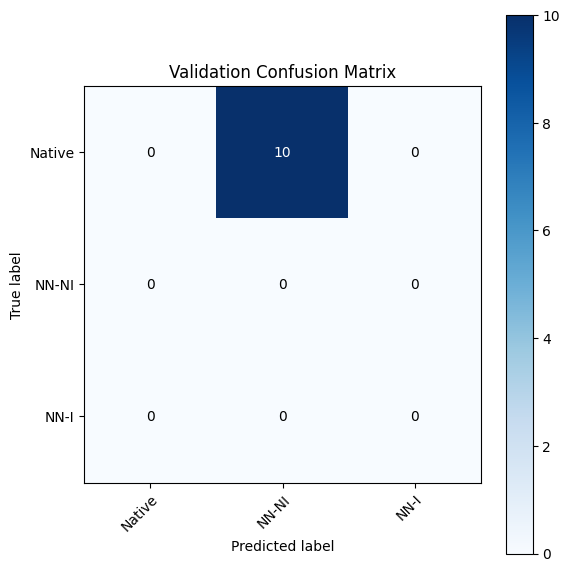


🔁 Epoch 2/3


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 507.17it/s]

📉 Train Loss: 1.0985 | Accuracy: 0.1250
📈 Val Loss:   1.0900 | Accuracy: 0.6000

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       1.00      0.60      0.75        10
NN Non-Invasive       0.00      0.00      0.00         0
    NN Invasive       0.00      0.00      0.00         0

       accuracy                           0.60        10
      macro avg       0.33      0.20      0.25        10
   weighted avg       1.00      0.60      0.75        10



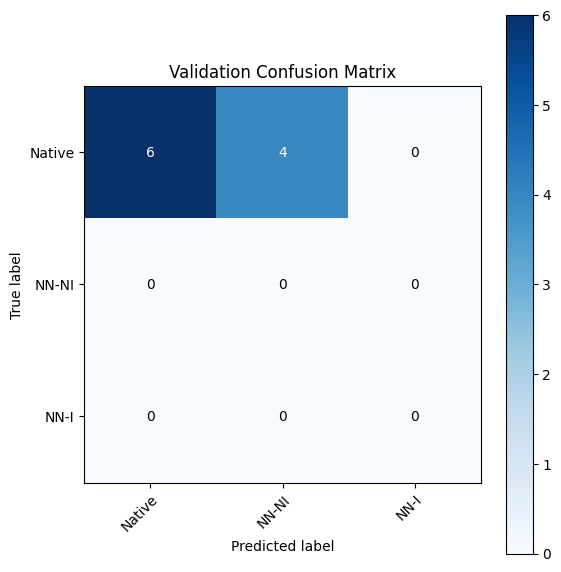


🔁 Epoch 3/3


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 610.35it/s]


📉 Train Loss: 1.0885 | Accuracy: 0.3750
📈 Val Loss:   1.0810 | Accuracy: 0.8000

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       1.00      0.80      0.89        10
NN Non-Invasive       0.00      0.00      0.00         0
    NN Invasive       0.00      0.00      0.00         0

       accuracy                           0.80        10
      macro avg       0.33      0.27      0.30        10
   weighted avg       1.00      0.80      0.89        10



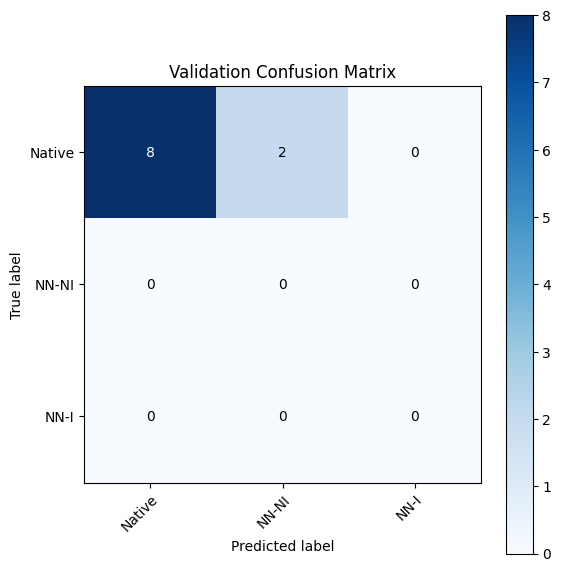

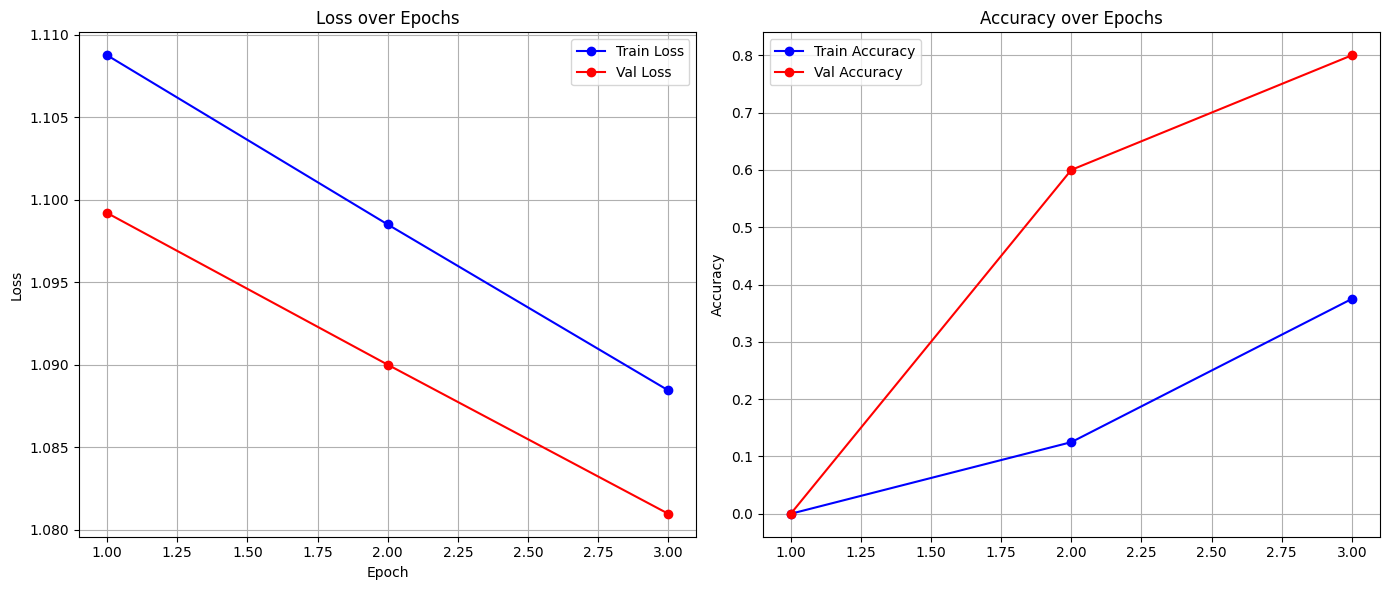

Full model built...
Total execution time: 755.95 seconds


In [26]:
# create_model_and_predict(folder_name="taxas", use_bioclip=True, output_dir="invasive_species", model_name="first_attempt_with_class_weighting")

model_name_BC1 = "class_weighting_small_test"
embeddings_save_path_BC1 = '/content/drive/MyDrive/Thesis/bioclip_1_embeddings.pt'
#remember to remove debug subset size
create_model_and_predict(folder_name="taxas", use_bioclip=True, bioclip_version=1, output_dir="invasive_species", model_name=model_name_BC1, embeddings_save_path=embeddings_save_path_BC1, debug_subset_size=50)

Using device: cuda
Model obtained...
Feature extractor obtained..
✅ Embeddings already exist, loading from file...
⚠ Debug mode: using only the first 50 embeddings.
SPLITTING EMBEDDINGS

🔁 Epoch 1/3


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 455.70it/s]

📉 Train Loss: 1.2116 | Accuracy: 0.0500
📈 Val Loss:   1.0882 | Accuracy: 0.3000

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       1.00      0.30      0.46        10
NN Non-Invasive       0.00      0.00      0.00         0
    NN Invasive       0.00      0.00      0.00         0

       accuracy                           0.30        10
      macro avg       0.33      0.10      0.15        10
   weighted avg       1.00      0.30      0.46        10



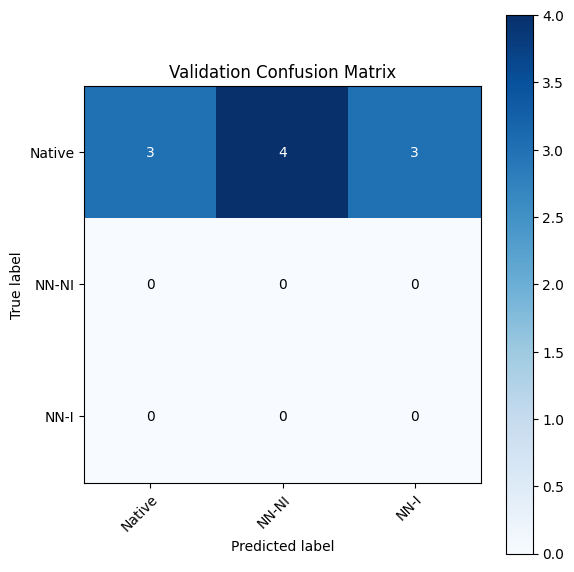


🔁 Epoch 2/3


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 606.99it/s]

📉 Train Loss: 1.0423 | Accuracy: 0.6000
📈 Val Loss:   0.9289 | Accuracy: 0.9000

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       1.00      0.90      0.95        10
NN Non-Invasive       0.00      0.00      0.00         0
    NN Invasive       0.00      0.00      0.00         0

       accuracy                           0.90        10
      macro avg       0.33      0.30      0.32        10
   weighted avg       1.00      0.90      0.95        10



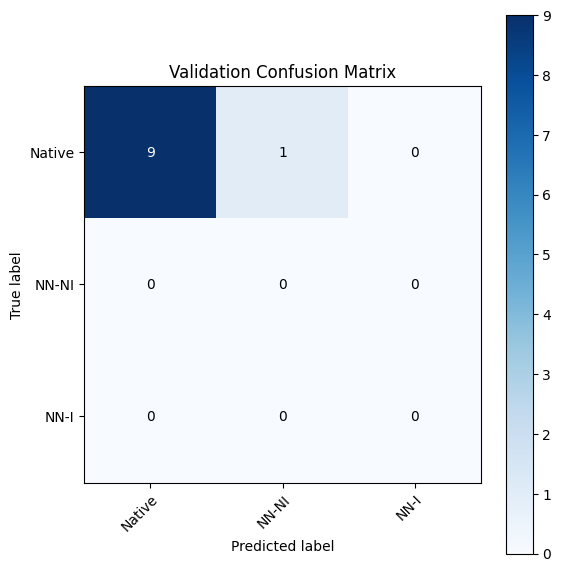


🔁 Epoch 3/3


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 489.36it/s]

📉 Train Loss: 0.8904 | Accuracy: 0.9250
📈 Val Loss:   0.7896 | Accuracy: 1.0000

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       1.00      1.00      1.00        10
NN Non-Invasive       0.00      0.00      0.00         0
    NN Invasive       0.00      0.00      0.00         0

       accuracy                           1.00        10
      macro avg       0.33      0.33      0.33        10
   weighted avg       1.00      1.00      1.00        10



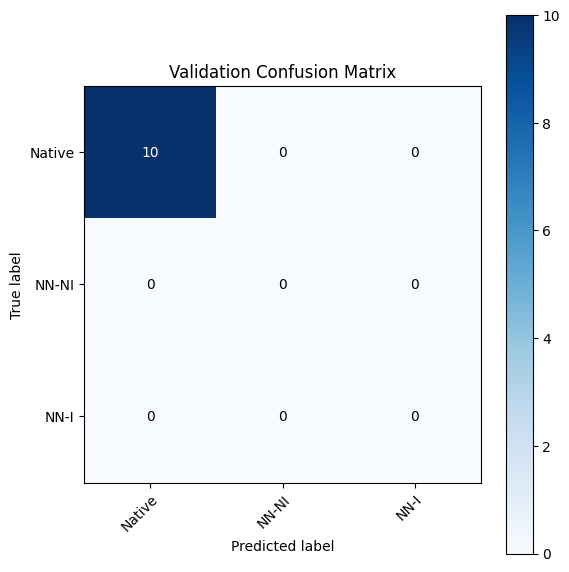

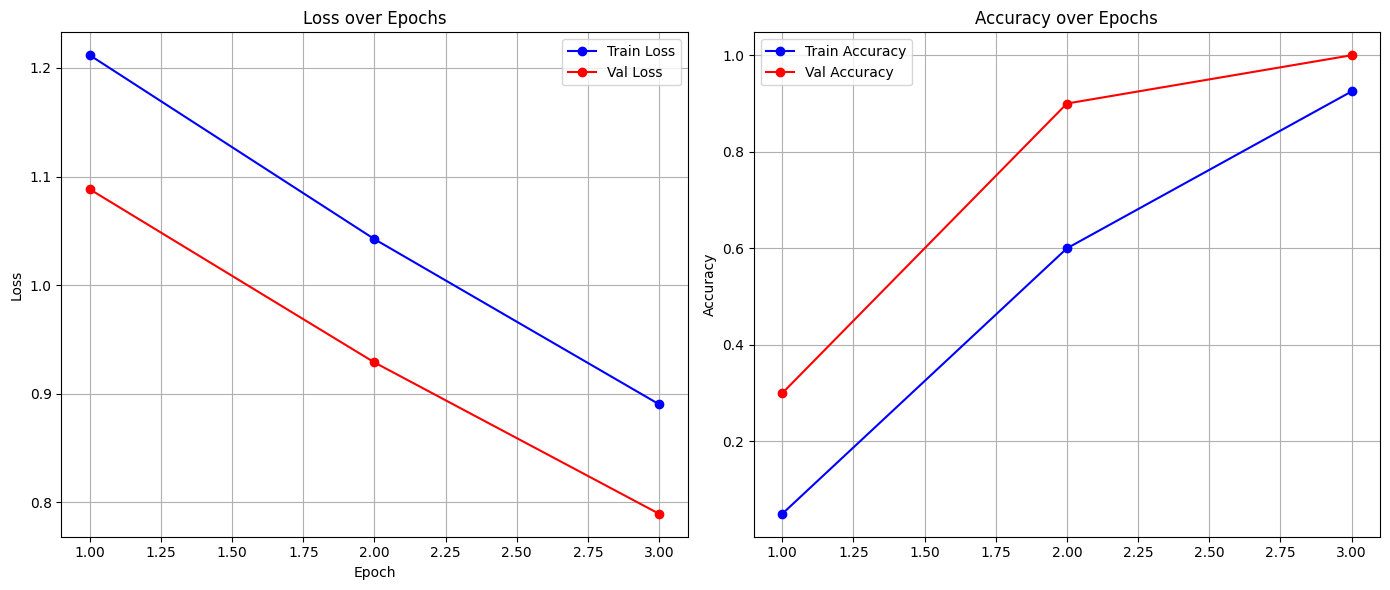

Full model built...
Total execution time: 1.95 seconds


In [28]:
# create_model_and_predict(folder_name="taxas", use_bioclip=False, output_dir="invasive_species", model_name="first_attempt_with_class_weighting")

model_name = "class_weighting_small_test"
embeddings_save_path = '/content/drive/MyDrive/Thesis/resnet_embeddings.pt'
#remember to remove debug subset size
create_model_and_predict(folder_name="taxas", use_bioclip=False, output_dir="invasive_species", model_name=model_name, embeddings_save_path=embeddings_save_path, debug_subset_size=50)

Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
🔎 Dataset root directory: /content/ai4biological-pattern/barbara_new/taxas
📁 Taxa folders found: ['lythrum_baeticum', 'lythrum_flagellare', 'lythrum_thesioides', 'lythrum_borysthenicum', 'lythrum_hyssopifolia', 'lythrum_rotundifolium', 'lythrum_thymifolia', 'lythrum_virgatum', 'lythrum_curtissii', 'lythrum_wilsonii', 'lythrum_intermedium', 'lythrum_alatum', 'lythrum_paradoxum', 'lythrum_lineare', 'lythrum_album', 'lythrum_gracile', 'lythrum_ovalifolium', 'lythrum_tribracteatum', 'lythrum_californicum', 'lythrum_maritimum', 'lythrum_netofa', 'lythrum_bryantii', 'lythrum_vulneraria', 'lythrum_portula', 'lythrum_volgense', 'lythrum_acutangulum', 'lythrum_flexuosum', 'lythrum_salicaria', 'lythrum_junceum', 'lythrum_silenoides']
Dataloader obtained..
Entered EXTRACT_EMBEDDINGS


Extracting embeddings: 100%|██████████| 1373/1373 [35:33<00:00,  1.55s/it]


⚠ Debug mode: using only the first 50 embeddings.
SPLITTING EMBEDDINGS

🔁 Epoch 1/3


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 550.00it/s]

📉 Train Loss: 1.0891 | Accuracy: 0.0000
📈 Val Loss:   1.0769 | Accuracy: 0.0000

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.00      0.00      0.00      10.0
NN Non-Invasive       0.00      0.00      0.00       0.0
    NN Invasive       0.00      0.00      0.00       0.0

       accuracy                           0.00      10.0
      macro avg       0.00      0.00      0.00      10.0
   weighted avg       0.00      0.00      0.00      10.0



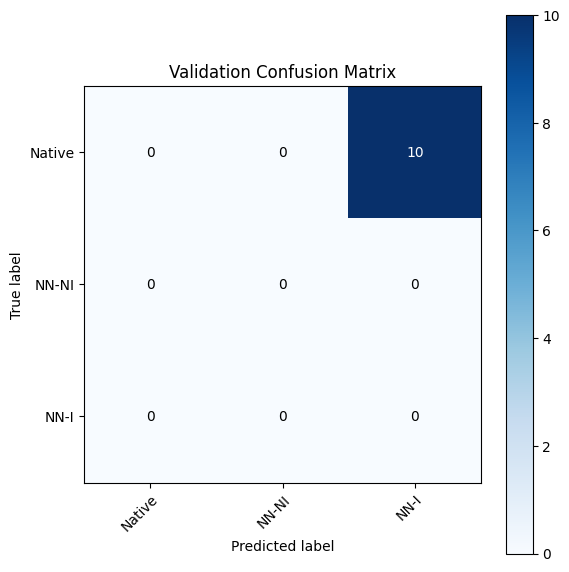


🔁 Epoch 2/3


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 615.45it/s]

📉 Train Loss: 1.0757 | Accuracy: 0.0250
📈 Val Loss:   1.0641 | Accuracy: 0.9000

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       1.00      0.90      0.95        10
NN Non-Invasive       0.00      0.00      0.00         0
    NN Invasive       0.00      0.00      0.00         0

       accuracy                           0.90        10
      macro avg       0.33      0.30      0.32        10
   weighted avg       1.00      0.90      0.95        10



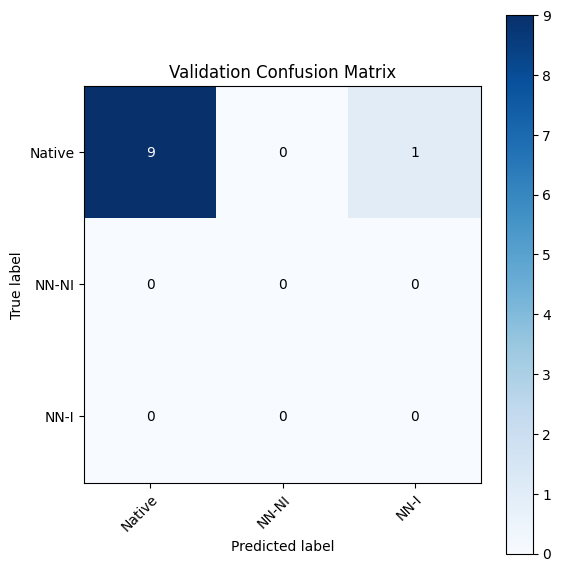


🔁 Epoch 3/3


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 599.36it/s]


📉 Train Loss: 1.0627 | Accuracy: 0.9250
📈 Val Loss:   1.0513 | Accuracy: 1.0000

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       1.00      1.00      1.00        10
NN Non-Invasive       0.00      0.00      0.00         0
    NN Invasive       0.00      0.00      0.00         0

       accuracy                           1.00        10
      macro avg       0.33      0.33      0.33        10
   weighted avg       1.00      1.00      1.00        10



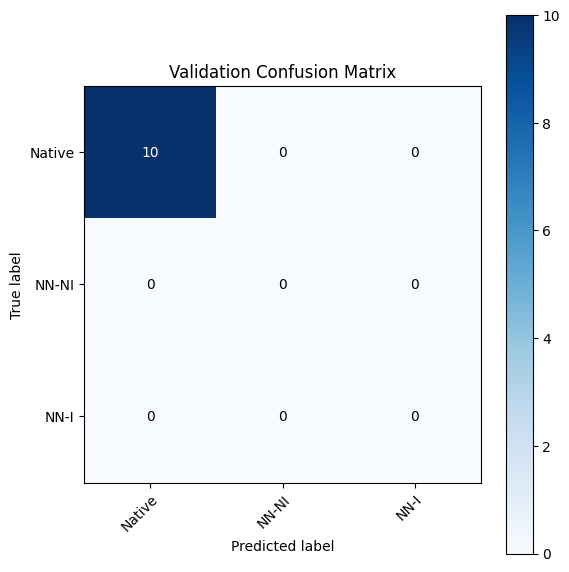

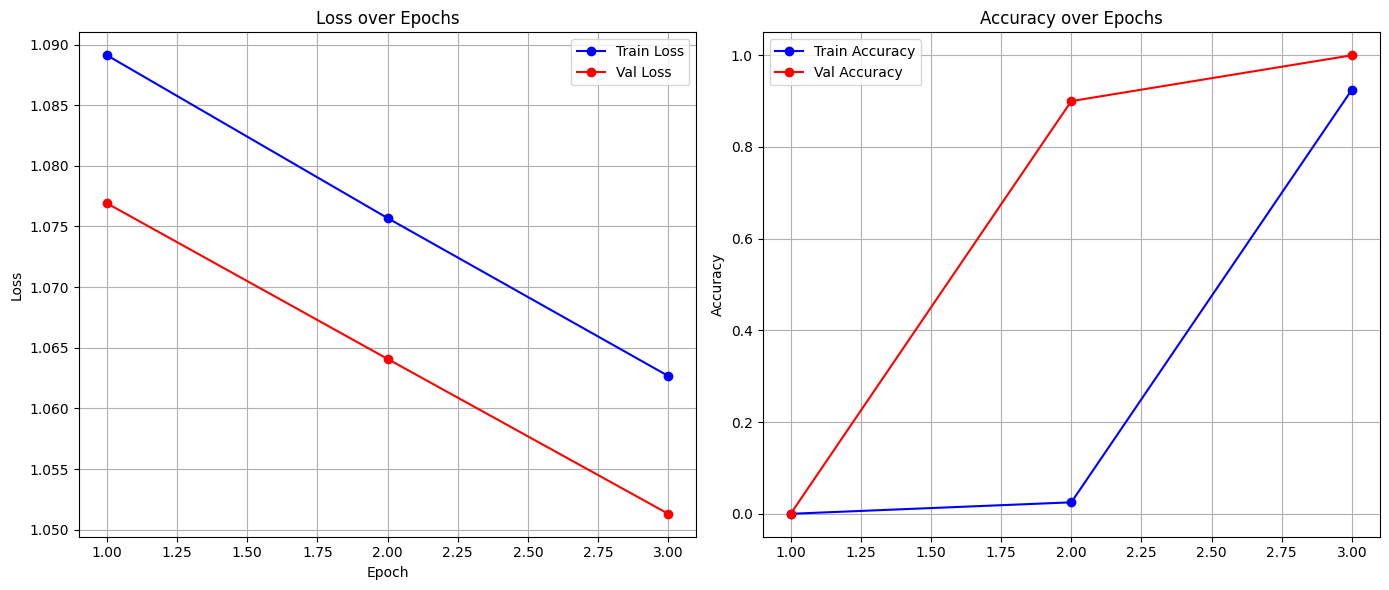

Full model built...
Total execution time: 2284.85 seconds


In [31]:
model_name_BC2 = "class_weighting_small_test"
embeddings_save_path_BC2 = '/content/drive/MyDrive/Thesis/bioclip_2_embeddings.pt'
create_model_and_predict(folder_name="taxas", use_bioclip=True, bioclip_version=2, output_dir="invasive_species", model_name=model_name, embeddings_save_path=embeddings_save_path_BC2, debug_subset_size=50)